In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
# Data Preprocessing

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median)

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
# Feature Enginnering

In [9]:
df["Age"] = 2026-df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference = df["Dt_Customer"].max()

df["cust_spending_days"] = (reference-df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'cust_spending_days'],
      dtype='object')

In [14]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +df["MntFishProducts"] +df["MntSweetProducts"] + df["MntGoldProds"]

In [15]:
df["Total_childs"] = df["Kidhome"] + df["Teenhome"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
df["Education"] = df["Education"].replace(
    {
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Post-Graduate",
    "PhD" : "Post-Graduate"
    }
)

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Post-Graduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [20]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [21]:
df["living_with"] = df["Marital_Status"].replace(
    {
    "Married" : "partner",
    "Together" : "partner",
    "Single" : "single",
    "Divorced" : "single",
    "Widow" : "single",
    "Alone" : "single",
    "Absurd" : "single",
    "YOLO" : "single"
    }
)

In [22]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs,living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,single
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,single
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,partner
4,5324,1981,Post-Graduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,partner


In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'cust_spending_days', 'Total_Spending',
       'Total_childs', 'living_with'],
      dtype='object')

In [24]:
df = df.drop(columns=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"],axis=1)

In [25]:
df.shape

(2240, 15)

In [26]:
df.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'cust_spending_days', 'Total_Spending', 'Total_childs', 'living_with'],
      dtype='object')

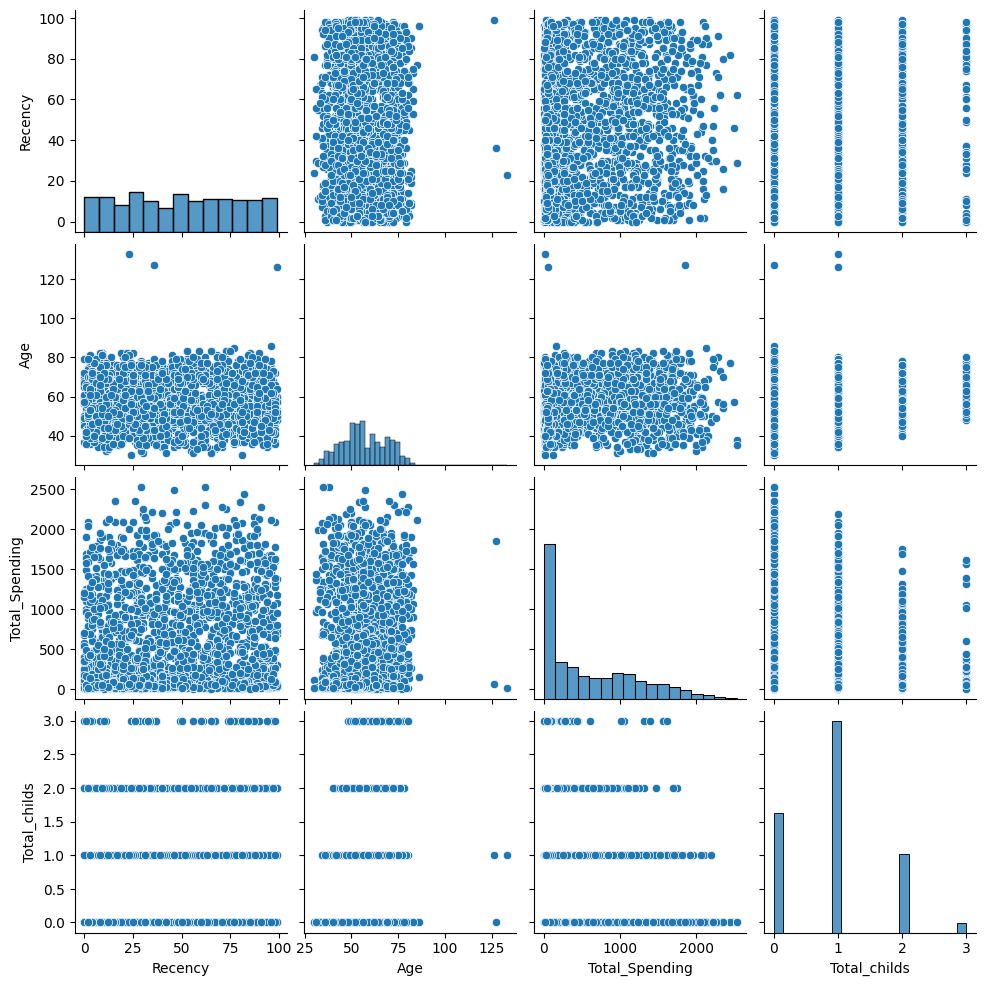

In [27]:
cols = ["Income","Recency","Age","Total_Spending","Total_childs","living_with"]

sns.pairplot(df[cols])

In [28]:
df["Income"] = pd.to_numeric(df["Income"], errors='coerce')
print("with Outlier count: ",len(df))
df = df[ ( df["Age"] < 90 ) ]
df = df[ ( df["Income"] < 600_000 ) ]
print("without Outlier count: ",len(df))

with Outlier count:  2240
without Outlier count:  2212


In [29]:
# Co relation Heatmap

<Axes: >

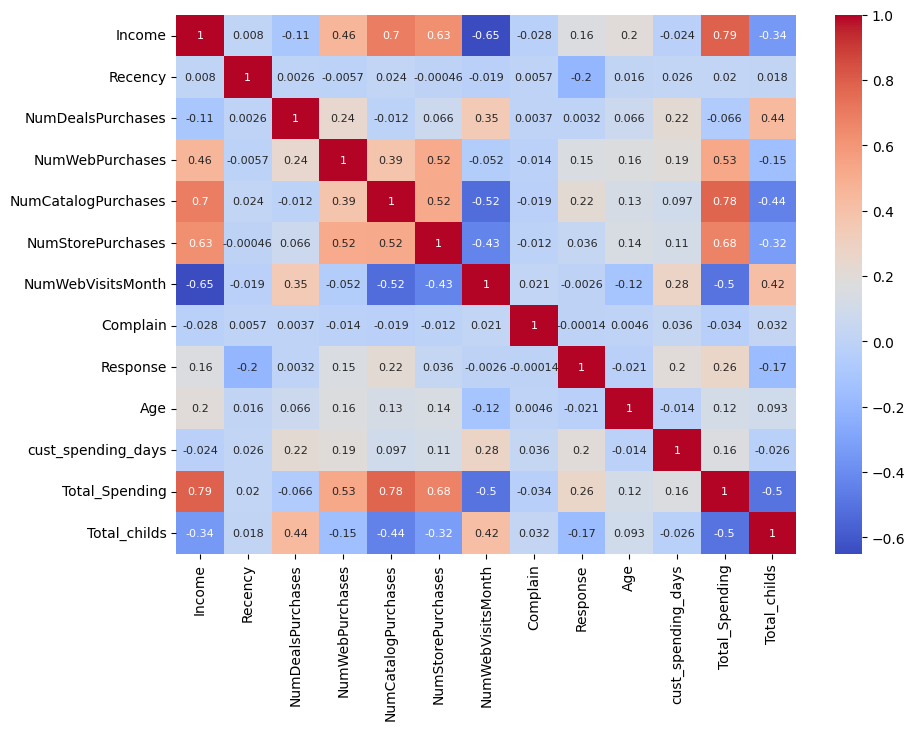

In [30]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":8},
    linecolor="black",
    cmap="coolwarm"
)



In [31]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs,living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,single
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Post-Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


In [33]:
cols = ["Education","living_with"]

ohe = OneHotEncoder()

ohe_data = ohe.fit_transform(df[cols]).toarray()

ohe_df = pd.DataFrame(ohe_data,columns=ohe.get_feature_names_out(cols))

df = df.drop(columns=cols,axis=1)

df = pd.concat([df,ohe_df],axis=1)

In [34]:
df.shape

(2238, 18)

In [35]:
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs,Education_Graduate,Education_Post-Graduate,Education_Undergraduate,living_with_partner,living_with_single
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0,1.0,0.0,0.0,0.0,1.0
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0,1.0,0.0,0.0,1.0,0.0
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0,0.0,1.0,0.0,1.0,0.0


In [36]:
# Standardization

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(df)

In [39]:
x_scaled

array([[ 0.28710487,  0.31035323,  0.35102992, ..., -0.35856858,
        -1.34960312,  1.34960312],
       [-0.26088203, -0.38081349, -0.16870113, ..., -0.35856858,
        -1.34960312,  1.34960312],
       [ 0.9131964 , -0.79551352, -0.68843217, ..., -0.35856858,
         0.74095857, -0.74095857],
       ...,
       [        nan,         nan,         nan, ...,  2.78886676,
         0.74095857, -0.74095857],
       [        nan,         nan,         nan, ..., -0.35856858,
        -1.34960312,  1.34960312],
       [        nan,         nan,         nan, ..., -0.35856858,
        -1.34960312,  1.34960312]])

In [40]:
from sklearn.decomposition import PCA

In [41]:
from sklearn.impute import SimpleImputer


In [42]:
imputer = SimpleImputer(strategy='mean')

x_imputed = imputer.fit_transform(x_scaled)

In [43]:
pca = PCA(n_components=9)
x_pca = pca.fit_transform(x_imputed)

In [44]:
print(sum(pca.explained_variance_ratio_)*100)

84.50216004879204


In [45]:
# plot

Text(0.5, 0.92, '3d projection')

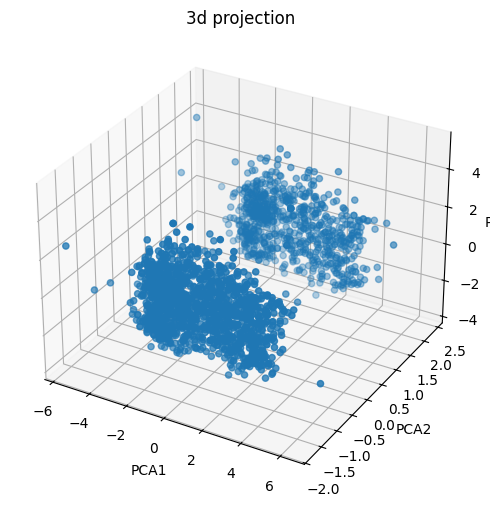

In [46]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [47]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [48]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [49]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [50]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
print("optimal K:",knee.elbow)

optimal K: 3


Text(0, 0.5, 'WCSS')

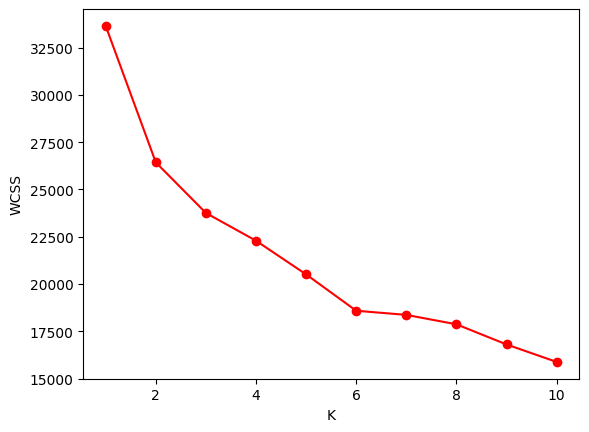

In [51]:
plt.plot(range(1, 11), wcss, marker='o',c="red")
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

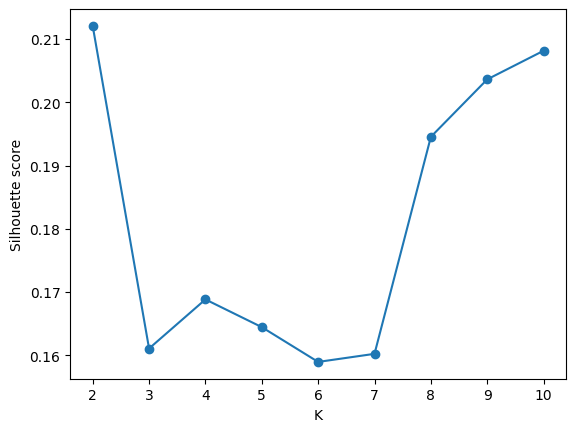

In [52]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

In [53]:
#Combine plot

Text(0, 0.5, 'SS')

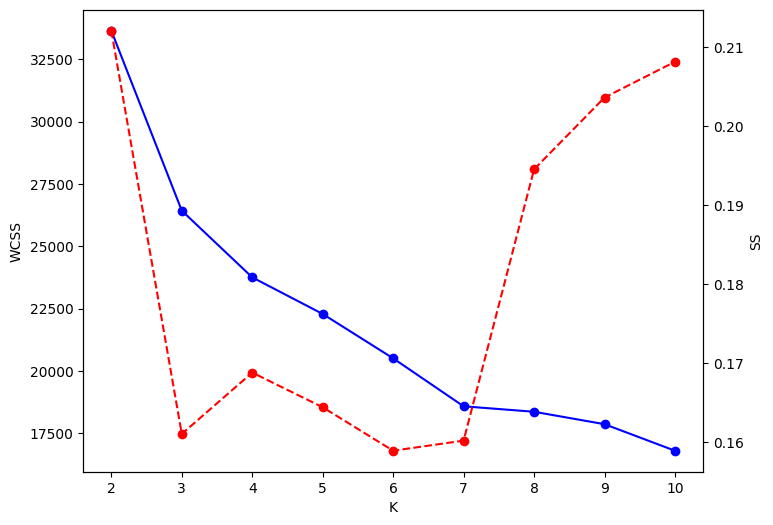

In [55]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="o", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [57]:
# K_means

kmeans = KMeans(n_clusters=7, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

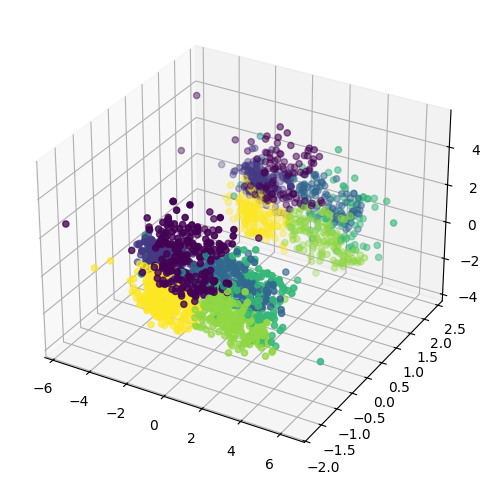

In [58]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_kmeans)

In [59]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [64]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

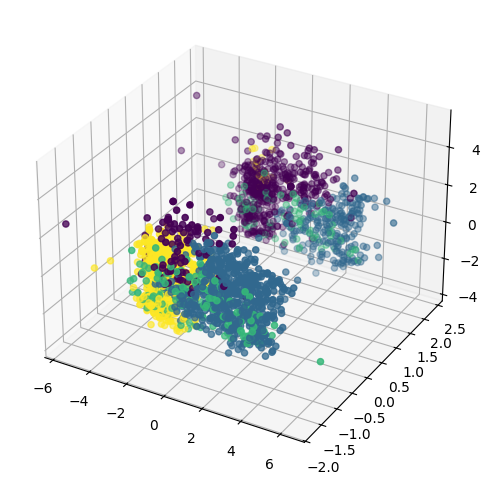

In [65]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_agg)

In [67]:
df["cluster"] = labels_agg

In [68]:
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cust_spending_days,Total_Spending,Total_childs,Education_Graduate,Education_Post-Graduate,Education_Undergraduate,living_with_partner,living_with_single,cluster
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0,1.0,0.0,0.0,0.0,1.0,0
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0,1.0,0.0,0.0,1.0,0.0,1
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0,1.0,0.0,0.0,1.0,0.0,3
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0,0.0,1.0,0.0,1.0,0.0,1


<Axes: xlabel='cluster', ylabel='count'>

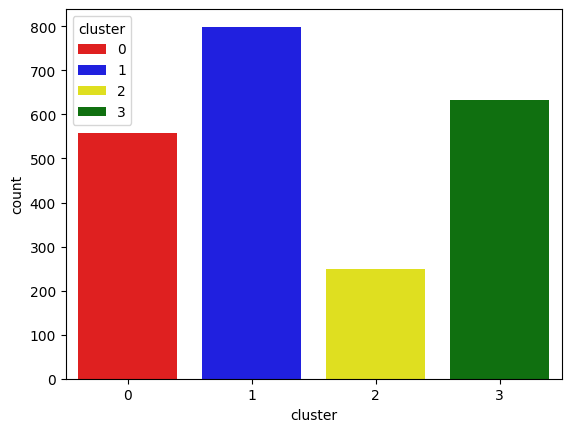

In [69]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=df["cluster"], palette=pal, hue=df["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

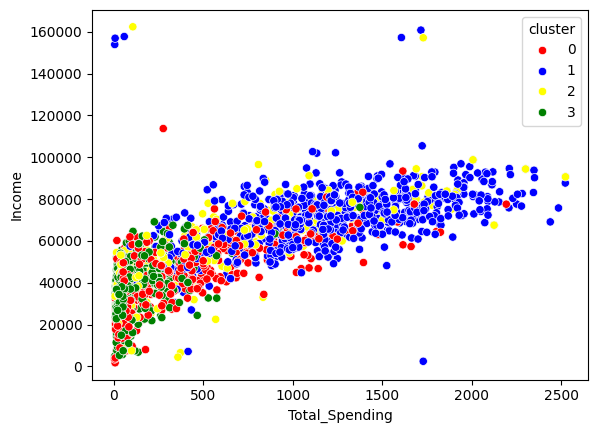

In [70]:
sns.scatterplot(x=df["Total_Spending"], y=df["Income"], hue=df["cluster"], palette=pal)

In [71]:
# Cluster Summary

cluster_summary = df.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        43816.789091  48.347273           3.365455         4.147273   
1        70566.289507  48.697851           1.883692         5.460177   
2        53986.493878  52.102041           2.093878         4.159184   
3        34806.755591  48.809904           2.057508         2.274760   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.612727           5.078182           6.474545  0.036364   
1                   5.036662           8.359039           3.649810  0.000000   
2                   2.608163           5.636735           5.167347  0.000000   
3                   0.640575           3.287540           6.480831  0.000000   

         Response        Age  cust_spending_days  Total_Spending  \
cluster           